In [1]:
import numpy as np
from scipy.optimize import fsolve, root

# import predefined functions wich solve the box model
import fct_BoxModel as fbm

import xarray as xr
import pandas as pd
import matplotlib
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
import cv2 as cv

from matplotlib import colors




matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

### Importing the model inputs

In [2]:
inputs = xr.open_dataset("model_input_dataset.nc")
index_isf = inputs.Nisf.values
name_isf = inputs.name_isf.values

### Defining constant parameters of the model

In [3]:
# Define reference properties and parameters 

#EOS
T_star = 0 # °C  (PICO)
S_star = 34 # PSU   (PICO)
rho_star = 1033 # kg/m^3   (PICO)
alpha = 7.5e-5 # /°C   (PICO)
beta = 7.7e-4 # /PSU (PICO)

def EOS(T,S):
    return rho_star*(1-alpha*(T-T_star)+beta*(S-S_star))
    
#Liquidus
la = -0.0572 # °C/PSU   (PICO)
lb = 0.0788 # °C   (PICO)
lc = 7.59e-4 # °C/m   (PICO->Burgard)

def liquidus(S,h):
    return la*S+lb-lc*h

#Water properties
L = 3.34e5 # J/kg   (PICO)
c_star = 3974 # J/kg/°C   (PICO)
lambd = L/c_star # 84 K

#Ice properties
rho_i = 910 # kg/m^3   (PICO)
nu = rho_i/rho_star #0.88

#PICO parameters
# Reese 2018
C = 1e6 #m^6/s/kg
gammaT = 2e-5 #m/s

#Vertical mixing
# ~Olbers & Hellmer 2010
kappa_diff = 1e-7  # m/s
kappa_conv = 1e-3 # m/s

#Polynia
g = 20

#AABW
C2 = 4e6 #m^6/s/kg

/tmp/ipykernel_70792/954579321.py:1: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp


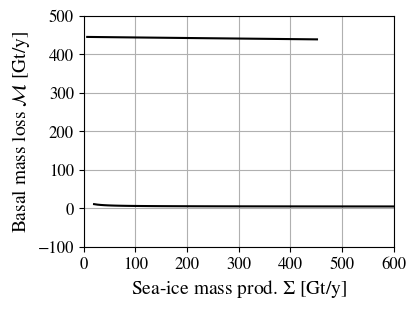

In [4]:
import imp
imp.reload(fbm)

index = 11 #Fichner-Ronne ice shelf


nbox = int(inputs.Nbox.sel(Nisf=index).values)
Ac = inputs.Ac.sel(Nisf=index).values #m^2
Omega = np.mean(inputs.Omega.sel(Nisf=index).values)/30/24/3600 *2/3 #m/s factor 2/3 to take summer into account
frac = inputs.frac.sel(Nisf=index).values
depth = inputs.depth.sel(Nisf=index).values
T_surf = np.mean(inputs.T_surf.sel(Nisf=index).values)
S_surf = np.mean(inputs.S_surf.sel(Nisf=index).values)
T0 = np.mean(inputs.T0.sel(Nisf=index).values)
S0 = np.mean(inputs.S0.sel(Nisf=index).values)

Ap_min = 0
Ap_max = 80e9
Npoints = 100
list_Ap = np.linspace(Ap_min,Ap_max,Npoints)

AABW = False

guess_diff = np.array([0.1,0,34.3,34.0])
guess_conv = np.array([0.1,34])


plt.figure(figsize=(4,3))

for func, guess, sign in zip([fbm.BoxModel_diff,fbm.BoxModel_conv],[guess_diff,guess_conv],[-1,1]):
        
        melt_list = []
        overt = []
        Sd_list = []
        DSW = []
        sig = []
        sig_d_0 = []
        for Ap in list_Ap:

            X, info, ier, msg = fsolve(func, guess, args = (nbox,C,gammaT,Ac,Omega,T0,S0,Ap, kappa_diff ,g,frac,depth, C2, T_surf, S_surf), full_output=True)
            if ier != 1: #management of non convergence cases
                while ier != 1:
                    X, info, ier, msg = fsolve(func, np.random.normal(guess,0.1), args = (nbox,C,gammaT,Ac,Omega,T0,S0,Ap,kappa_diff,g,frac,depth, C2, T_surf, S_surf), full_output=True)
                print(msg,sign,Ap)
            guess = X

            if sign == -1: #diff
                 Tp, Td, Sp, Sd = X
                 sigma = fbm.compute_Sigma(X)
            else: #conv
                Td, Sd = X
                sigma = 0
                 

            T,S,melt,q = fbm.PICO(Td, Sd, nbox, C, gammaT, Ac, frac, depth)
            q_DSW = fbm.compute_DSW(Td, Sd, C2, T0, S0)
            sigma_d_0 = fbm.compute_rhod_rho0(Td,Sd,T0,S0)
            m_avg = fbm.compute_m_avg(melt,frac,nbox)
            
            
            melt_list.append(m_avg*12) #m/y
            overt.append(q/1e6) #Sv
            Sd_list.append(Sd) #PSU
            DSW.append(q_DSW/1e6) #Sv
            sig.append(sigma)
            sig_d_0.append(sigma_d_0)
        
        stab = np.array(sig_d_0)*sign > 0
        #melt_list = np.ma.masked_where(np.logical_not(stab),np.array(melt_list))
        #overt = np.ma.masked_where(np.logical_not(stab),np.array(overt))
        #Sd_list = np.ma.masked_where(np.logical_not(stab),np.array(Sd_list))
        #DSW = np.ma.masked_where(np.logical_not(stab),np.array(DSW))
        
        x_axis = np.ma.masked_where(np.logical_not(stab),list_Ap) *Omega*rho_i/1e12*3600*24*365.25 # Gt/y
        y_axis = melt_list*Ac*rho_i/1e12 # Gt/y
    
        plt.plot(x_axis,y_axis,c='black')



#plt.hlines(0,0,np.max(x_axis), colors='black',linestyle='dotted')
plt.ylim((-100,500))
plt.xlim((0,600))
plt.xlabel(r'Sea-ice mass prod. $\Sigma$ [Gt/y]')
plt.ylabel(r'Basal mass loss $\mathcal{M}$ [Gt/y]')
plt.grid()
plt.savefig('Figures/Figure2.pdf',format="pdf", bbox_inches = 'tight')
plt.show()


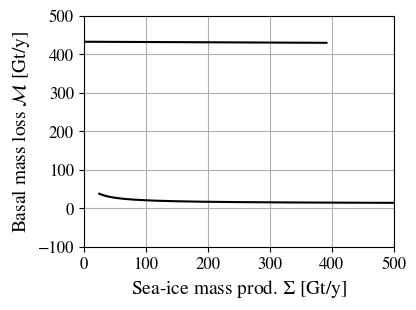

In [263]:
#try with eddy intrusion of CDW

import imp
imp.reload(fbm)

index = 31 #Amery ice shelf

r = 0.1


nbox = int(inputs.Nbox.sel(Nisf=index).values)
Ac = inputs.Ac.sel(Nisf=index).values #m^2
Omega = np.mean(inputs.Omega.sel(Nisf=index).values)/30/24/3600 *2/3 #m/s factor 2/3 to take summer into account
frac = inputs.frac.sel(Nisf=index).values
depth = inputs.depth.sel(Nisf=index).values
T_surf = np.mean(inputs.T_surf.sel(Nisf=index).values)
S_surf = np.mean(inputs.S_surf.sel(Nisf=index).values)
T0 = np.mean(inputs.T0.sel(Nisf=index).values)
S0 = np.mean(inputs.S0.sel(Nisf=index).values)

Ap_min = 0.
Ap_max = 40e9
Npoints = 1000
list_Ap = np.linspace(Ap_min,Ap_max,Npoints)

AABW = False

guess_diff = np.array([0,0,34.5,34.54])
guess_conv = np.array([-1.8,-1.5,34.3,35.5])


plt.figure(figsize=(4,3))

for kappa, guess, sign, mode in zip([kappa_diff, kappa_conv],[guess_diff,guess_conv],[-1,1],['diff','conv']):
    

    melt_list = []
    overt = []
    Sd_list = []
    DSW = []
    sig = []
    sig_d_0 = []
    
    for Ap in list_Ap:

        X, info, ier, msg = fsolve(fbm.BoxModel, guess, args = (nbox,C,gammaT,Ac,Omega,T0,S0,Ap, kappa ,g,frac,depth, C2, T_surf, S_surf, r,mode), full_output=True)
        if ier != 1: #management of non convergence cases
            while ier != 1:
                X, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess,0.1), args = (nbox,C,gammaT,Ac,Omega,T0,S0,Ap, kappa ,g,frac,depth, C2, T_surf, S_surf, r, mode), full_output=True)
            print(msg,mode,Ap)
        guess = X

        Tp, Td, Sp, Sd = X
        sigma = fbm.compute_Sigma(X)
                

        T,S,melt,q = fbm.PICO(Td, Sd, nbox, C, gammaT, Ac, frac, depth)
        q_DSW = fbm.compute_DSW(Td, Sd, C2, T0, S0)
        sigma_d_0 = fbm.compute_rhod_rho0(Td,Sd,T0,S0)
        m_avg = fbm.compute_m_avg(melt,frac,nbox)
        
        
        melt_list.append(m_avg*12) #m/y
        overt.append(q/1e6) #Sv
        Sd_list.append(Sd) #PSU
        DSW.append(q_DSW/1e6) #Sv
        sig.append(sigma)
        sig_d_0.append(sigma_d_0)
    
    stab = (np.array(sig_d_0)*sign > 0)
    melt_list = np.ma.masked_where(np.logical_not(stab),np.array(melt_list))
    overt = np.ma.masked_where(np.logical_not(stab),np.array(overt))
    Sd_list = np.ma.masked_where(np.logical_not(stab),np.array(Sd_list))
    DSW = np.ma.masked_where(np.logical_not(stab),np.array(DSW))
    
    x_axis = np.ma.masked_where(np.logical_not(stab),list_Ap) *Omega*rho_i/1e12*3600*24*365.25 # Gt/y
    y_axis = melt_list*Ac*rho_i/1e12 # Gt/y

    plt.plot(x_axis,y_axis,c='black')



#plt.hlines(0,0,np.max(x_axis), colors='black',linestyle='dotted')
plt.ylim((-100,500))
plt.xlim((0,500))
plt.xlabel(r'Sea-ice mass prod. $\Sigma$ [Gt/y]')
plt.ylabel(r'Basal mass loss $\mathcal{M}$ [Gt/y]')
plt.grid()
plt.savefig('Figures/Figure2.pdf',format="pdf", bbox_inches = 'tight')
plt.show()

/mnt/c/Users/louis/Documents/GitHub/Low-Dimensionnal-Model-2025/fct_BoxModel.py:44: RuntimeWarning: invalid value encountered in sqrt
  x0 = -g1[0]/(2*C*rho_star*(beta*s-alpha))+np.sqrt((g1[0]/(2*C*rho_star*(beta*s-alpha)))**2-g1[0]*T_st_0/(C*rho_star*(beta*s-alpha)))


The solution converged. DSW 801603206.4128256
The solution converged. DSW 40000000000.0


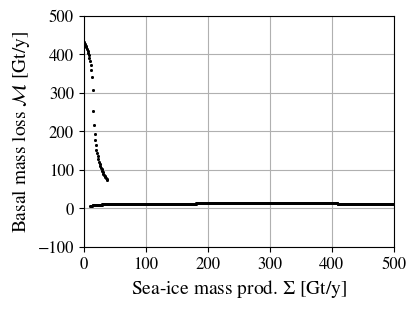

In [257]:
#try with eddy intrusion of CDW

import imp
imp.reload(fbm)

index = 31 #Amery ice shelf

Lamb = 0.4 #kg/m^3
r = 0. # eddy intrusion of CDW


nbox = int(inputs.Nbox.sel(Nisf=index).values)
Ac = inputs.Ac.sel(Nisf=index).values #m^2
Omega = np.mean(inputs.Omega.sel(Nisf=index).values)/30/24/3600 *2/3 #m/s factor 2/3 to take summer into account
frac = inputs.frac.sel(Nisf=index).values
depth = inputs.depth.sel(Nisf=index).values
T_surf = np.mean(inputs.T_surf.sel(Nisf=index).values)
S_surf = np.mean(inputs.S_surf.sel(Nisf=index).values)
T0 = np.mean(inputs.T0.sel(Nisf=index).values)
S0 = np.mean(inputs.S0.sel(Nisf=index).values)


Ap_min = 0.
Ap_max = 40e9
Npoints = 500
list_Ap_fw = np.linspace(Ap_min,Ap_max,Npoints)
list_Ap_bw = np.linspace(Ap_max,Ap_min,Npoints)




plt.figure(figsize=(4,3))

for mode, sign in zip(['CDW','DSW'],[-1,1]):

    for list_Ap in [list_Ap_fw,list_Ap_bw]:

        guess = np.array([0,0.1,34.5,34.5])
        

        melt_list = []
        overt = []
        Sd_list = []
        DSW = []
        sig = []
        sig_d_0 = []
        
        for Ap in list_Ap:

            incr = 0
            X, info, ier, msg = fsolve(fbm.BoxModel_continuous_kappa, guess, args = (nbox, C, gammaT, Ac, Omega, T0, S0, Ap, kappa_diff, kappa_conv, Lamb, g, frac, depth, C2, T_surf, S_surf, r, mode), full_output=True)
            if ier != 1: #management of non convergence cases
                while ier != 1:
                    incr += 1
                    X, info, ier, msg = fsolve(fbm.BoxModel_continuous_kappa, np.random.normal(guess,0.1), args = (nbox, C, gammaT, Ac, Omega, T0, S0, Ap, kappa_diff, kappa_conv, Lamb, g, frac, depth, C2, T_surf, S_surf, r, mode), full_output=True)

                    if incr > 50: # avoid infinite loops
                        X = np.nan*np.ones_like(guess) # set to nan to skip this point
                        break

                print(msg,mode,Ap)
            
            if ier == 1:
                guess = X

            Tp, Td, Sp, Sd = X
            sigma = fbm.compute_Sigma(X)
                    

            T,S,melt,q = fbm.PICO(Td, Sd, nbox, C, gammaT, Ac, frac, depth)
            q_DSW = fbm.compute_DSW(Td, Sd, C2, T0, S0)
            sigma_d_0 = fbm.compute_rhod_rho0(Td,Sd,T0,S0)
            m_avg = fbm.compute_m_avg(melt,frac,nbox)
            
            
            melt_list.append(m_avg*12) #m/y
            overt.append(q/1e6) #Sv
            Sd_list.append(Sd) #PSU
            DSW.append(q_DSW/1e6) #Sv
            sig.append(sigma)
            sig_d_0.append(sigma_d_0)
        
        
        stab = (np.array(sig_d_0)*sign > 0)
        melt_list = np.ma.masked_where(np.logical_not(stab),np.array(melt_list))
        overt = np.ma.masked_where(np.logical_not(stab),np.array(overt))
        Sd_list = np.ma.masked_where(np.logical_not(stab),np.array(Sd_list))
        DSW = np.ma.masked_where(np.logical_not(stab),np.array(DSW))
        
        x_axis = np.ma.masked_where(np.logical_not(stab),list_Ap) *Omega*rho_i/1e12*3600*24*365.25 # Gt/y
        
        #x_axis = list_Ap *Omega*rho_i/1e12*3600*24*365.25 # Gt/y
        y_axis = melt_list*Ac*rho_i/1e12 # Gt/y

        plt.scatter(x_axis,y_axis,c='black', s=1, zorder=2)



#plt.hlines(0,0,np.max(x_axis), colors='black',linestyle='dotted')
plt.ylim((-100,500))
plt.xlim((0,500))
plt.xlabel(r'Sea-ice mass prod. $\Sigma$ [Gt/y]')
plt.ylabel(r'Basal mass loss $\mathcal{M}$ [Gt/y]')
plt.grid()
plt.savefig('Figures/Figure2.pdf',format="pdf", bbox_inches = 'tight')
plt.show()

In [252]:
melt_list

masked_array(data=[0.02809298283045327, 0.028149213522649118,
                   0.02820569670668204, 0.028262434030629575,
                   0.028319427157627974, 0.028376677764966232,
                   0.02843418754433724, 0.028491958201905206,
                   0.028549991458484997, 0.028608289049760788,
                   0.02866685272633196, 0.028725684254003257,
                   0.028784785413711378, 0.028844158002026533,
                   0.028903803831091722, 0.028963724728767674,
                   0.029023922538844893, 0.029084399121386446,
                   0.029145156352675616, 0.029206196125407605,
                   0.029267520349051324, 0.02932913094981822,
                   0.029391029871061437, 0.029453219073075368,
                   0.029515700533893897, 0.02957847624884195,
                   0.029641548231119568, 0.029704918511927605,
                   0.029768589140661154, 0.0298325621849591,
                   0.02989683973109132, 0.029961423884099052,
 